In [1]:

import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns
from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


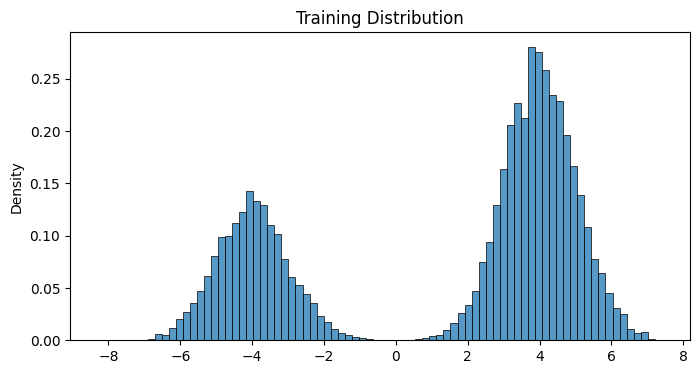

In [2]:

# Generate a 1D dataset from a mixture of Gaussians

data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1., 2.])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

dataset = data_distribution.sample(torch.Size([10000])).unsqueeze(1)
dataset_validation = data_distribution.sample(torch.Size([1000])).unsqueeze(1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(dataset.squeeze().numpy(), bins=80, stat="density", ax=ax)
ax.set_title("Training Distribution")
plt.show()


In [11]:

# Diffusion hyperparameters

TIME_STEPS = 250
BETA = 0.02
N_EPOCHS = 200
BATCH_SIZE = 64
LEARNING_RATE = 8e-5


betas = torch.full((TIME_STEPS,), BETA, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)



In [ ]:


class NoisePredictor(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1)
        )

    def forward(self, x, t):
        # Normalize timestep to [0, 1]
        t = t.float().unsqueeze(1) / TIME_STEPS
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

g = NoisePredictor().to(device)
print(g)


NoisePredictor(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Algorithm 1

In [5]:

optimizer = torch.optim.Adam(g.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []

epochs = tqdm(range(N_EPOCHS))

for epoch in epochs:

    g.train()

    indices = torch.randperm(dataset.shape[0])
    shuffled_dataset = dataset[indices]

    epoch_loss = 0.0
    n_batches = 0

    for i in range(0, shuffled_dataset.shape[0], BATCH_SIZE):

        x0 = shuffled_dataset[i:i + BATCH_SIZE].to(device)

        if x0.shape[0] == 0:
            continue

        # Algorithm 1
        t = torch.randint(0, TIME_STEPS, (x0.shape[0],), device=device)

        epsilon = torch.randn_like(x0)

        alpha_bar_t = alpha_bars[t].unsqueeze(1)

        # q(x_t | x_0)
        xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * epsilon

        # Predict noise
        epsilon_pred = g(xt, t)

        # DDPM simplified objective
        loss = torch.nn.functional.mse_loss(epsilon_pred, epsilon)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_loss = epoch_loss / n_batches
    train_losses.append(train_loss)

    # Validation
    g.eval()
    with torch.no_grad():

        x0 = dataset_validation.to(device)

        t = torch.randint(0, TIME_STEPS, (x0.shape[0],), device=device)
        epsilon = torch.randn_like(x0)

        alpha_bar_t = alpha_bars[t].unsqueeze(1)

        xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * epsilon

        epsilon_pred = g(xt, t)

        val_loss = torch.nn.functional.mse_loss(epsilon_pred, epsilon).item()
        val_losses.append(val_loss)

    epochs.set_description(
        f"train={train_loss:.5f} val={val_loss:.5f}"
    )


  0%|          | 0/200 [00:00<?, ?it/s]

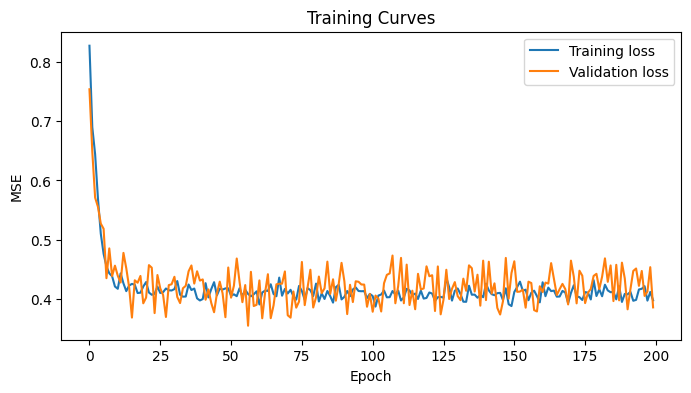

In [6]:

# Plot training curve

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(train_losses, label="Training loss")
ax.plot(val_losses, label="Validation loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Training Curves")
ax.legend()

plt.show()


## Algorithm

In [8]:

def sample_reverse(g, count, return_history=False):
    '''
    Sample from the trained diffusion model using Algorithm 2.
    '''

    g.eval()

    with torch.no_grad():

        # x_T ~ N(0, I)
        x = torch.randn(count, 1, device=device)

        history = [x.detach().cpu().clone()]

        for t in reversed(range(TIME_STEPS)):

            t_batch = torch.full((count,), t, device=device, dtype=torch.long)

            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]
            beta_t = betas[t]

            epsilon_theta = g(x, t_batch)

            if t > 0:
                z = torch.randn_like(x)
            else:
                z = torch.zeros_like(x)

            # Algorithm 2 update
            x = (
                (1 / torch.sqrt(alpha_t))
                * (
                    x
                    - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t))
                    * epsilon_theta
                )
                + torch.sqrt(beta_t) * z
            )

            if return_history:
                history.append(x.detach().cpu().clone())

    if return_history:
        return x.cpu(), history

    return x.cpu()


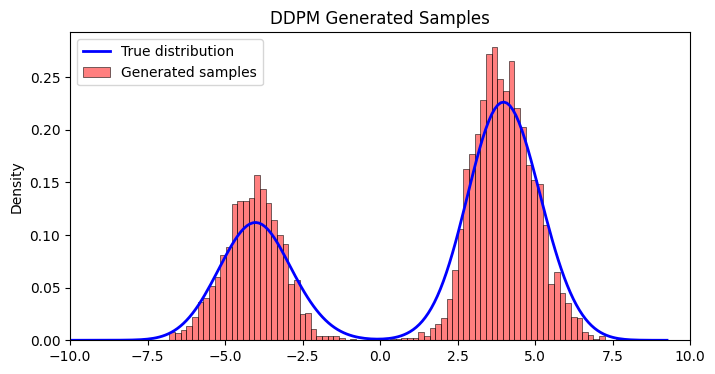

In [9]:

# Generate samples

samples = sample_reverse(g, 5000)
samples_np = samples.numpy().flatten()

fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(
    dataset.squeeze().numpy(),
    ax=ax,
    color="blue",
    label="True distribution",
    linewidth=2
)

sns.histplot(
    samples_np,
    bins=80,
    stat="density",
    color="red",
    alpha=0.5,
    label="Generated samples"
)

ax.set_xlim(-10, 10)
ax.set_title("DDPM Generated Samples")
ax.legend()

plt.show()


## Reverse Diffusion Visualization

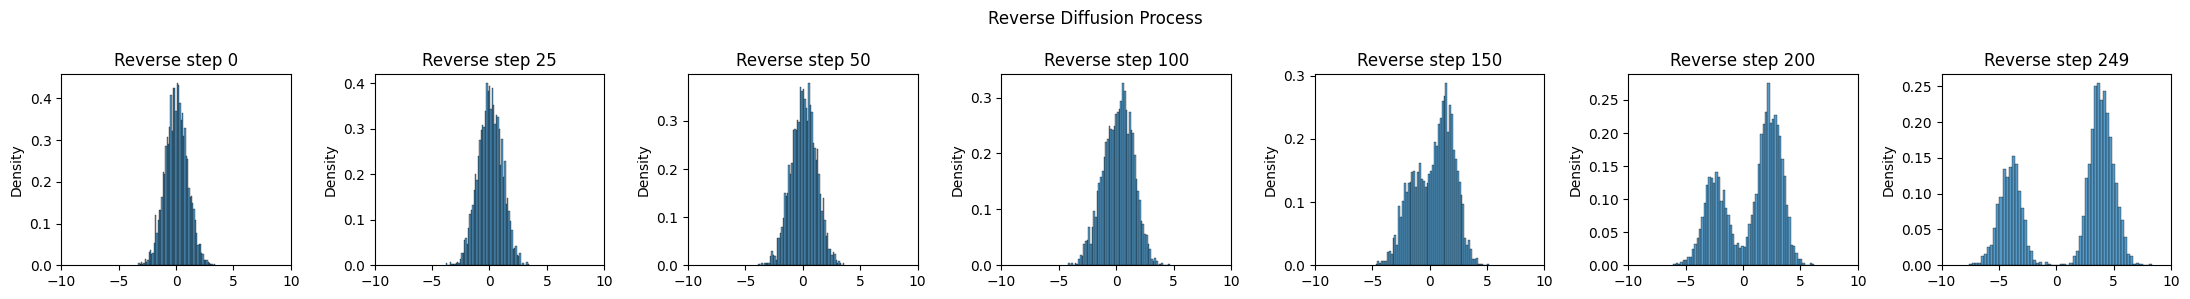

In [10]:

# Visualize how samples evolve during reverse diffusion

_, history = sample_reverse(g, 3000, return_history=True)

indices = [0, 25, 50, 100, 150, 200, 249]

fig, axes = plt.subplots(1, len(indices), figsize=(22, 3))

for ax, idx in zip(axes, indices):

    # History is stored from T -> 0
    h = history[idx].numpy().flatten()

    sns.histplot(h, bins=60, stat="density", ax=ax)

    ax.set_xlim(-10, 10)
    ax.set_title(f"Reverse step {idx}")

fig.suptitle("Reverse Diffusion Process")
plt.tight_layout()
plt.show()
